In [1]:
import sys
sys.path.append('/home/bens/pixel')

from scripts.evaluation.generate_attention_comparison import load_models, create_comparison_figure

import pandas as pd
from pathlib import Path

OUTPUT_DIR = '../attention_visualizations'
SELECTIONS_DIR = '../error_analysis/selections'

# make sure output directory exists
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# load master_predicitons.csv
master_df = pd.read_csv('../error_analysis/master_predictions.csv')

%load_ext autoreload
%autoreload 2

/opt/anaconda3/envs/pixel-env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
master_df[master_df['id']==30700130018]

,id,sentence,label,pred_arabic-default,confidence_arabic-default,pred_arabic-norm-dediac,confidence_arabic-norm-dediac,pred_arabic-nonorm-diac,confidence_arabic-nonorm-diac,pred_buckwalter-default,...,pred_hsb-nonorm-diac,confidence_hsb-nonorm-diac,pred_word-baseline,confidence_word-baseline,pred_d3tok-tatweel,confidence_d3tok-tatweel,pred_d3tok-space,confidence_d3tok-space,pred_d3tok-ascii,confidence_d3tok-ascii
6954,30700130018,17 فَصَلَّى إِبْرَاهِيمُ إِلَى اللهِ، فَشَفَى ...,11,11,0.665127,11,0.643085,11,0.688395,11,...,11,0.762911,11,0.5995,11,0.611401,11,0.457528,11,0.539334


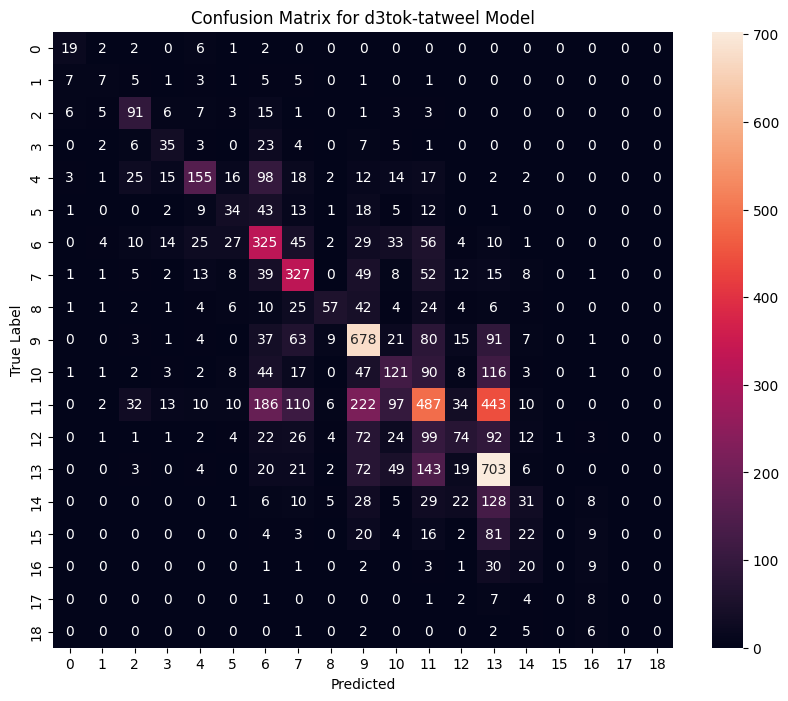

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# generate confusion matrix for arabic-default predictions for all examples in master_df
cm = confusion_matrix(master_df['label'], master_df['pred_hsb-nonorm-diac'])
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True Label')
plt.title('Confusion Matrix for d3tok-tatweel Model')
plt.show()

# Disambiguation Variants

In [ ]:
diac_variants = [
    "hsb-norm-dediac",
    "hsb-default",
    "hsb-nonorm-diac",
]

master_df['interesting'] = (
    (master_df['label'] != master_df['pred_hsb-norm-dediac']) &
    (master_df['label'] != master_df['pred_hsb-default']) &
    (master_df['label'] == master_df['pred_hsb-nonorm-diac']) &
    # and confidence > 0.6 for all models
    (master_df['confidence_hsb-nonorm-diac'] > 0.6) &
    # (master_df['confidence_d3tok-space'] > 0.5) &
    (master_df['label'].isin([0,1,2,3,4,5,6,7])) 
    # sentence length > 80
    # (master_df['sentence'].str.len() > 80)
)

interesting_examples_ids = [10102540058, 10700020100]

# master_df['interesting'] = master_df['id'].isin(interesting_examples_ids)

labeled_sentences = master_df[master_df['interesting']][['id', 'label', 'sentence']].sort_values(by='label', ascending=False)

2025-10-15 19:34:17,931 - INFO - Loading models and renderers...
2025-10-15 19:34:17,932 - INFO - Loading model for arabic-default...
2025-10-15 19:34:19,819 - INFO - Loading renderer for arabic-default...
2025-10-15 19:34:19,821 - INFO - loading text renderer configuration file ../runs/pixel-base-arabic-default-256-64-1-5e-05-7-42/text_renderer_config.json
2025-10-15 19:34:19,821 - INFO - loading font file ../runs/pixel-base-arabic-default-256-64-1-5e-05-7-42/GoNotoCurrent.ttf
2025-10-15 19:34:19,822 - INFO - Loading font from ../runs/pixel-base-arabic-default-256-64-1-5e-05-7-42/GoNotoCurrent.ttf
2025-10-15 19:34:19,866 - INFO - Text renderer PangoCairoTextRenderer {
  "background_color": "white",
  "dpi": 120,
  "font_color": "black",
  "font_features": null,
  "font_file": "GoNotoCurrent.ttf",
  "font_size": 8,
  "fonts_list": [
    "Abyssinica SIL",
    "Ani",
    "AnjaliOldLipi",
    "Bitstream Vera Sans",
    "Bitstream Vera Sans Mono",
    "Bitstream Vera Serif",
    "C059",
  

17 فَصَلَّى إِبْرَاهِيمُ إِلَى اللهِ، فَشَفَى اللهُ أَبِيمَالِكَ وَامْرَأَتَهُ وَجَوَارِيَهُ فَوَلَدْنَ.


[ WARN:0@26.197] global loadsave.cpp:848 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.
2025-10-15 19:34:38,694 - INFO - Loading CAMeL Tools disambiguator...
2025-10-15 19:34:41,758 - INFO - Loading CAMeL Tools disambiguator...
2025-10-15 19:34:44,537 - INFO - Loading CAMeL Tools disambiguator...
2025-10-15 19:34:48,143 - INFO - Loading CAMeL Tools disambiguator...
2025-10-15 19:34:50,881 - INFO - Setting up morphological tokenizer...
2025-10-15 19:34:50,976 - INFO - Loading CAMeL Tools disambiguator...
2025-10-15 19:34:55,111 - INFO - Setting up morphological tokenizer...
2025-10-15 19:34:55,204 - INFO - Loading CAMeL Tools disambiguator...
2025-10-15 19:34:58,450 - INFO - Setting up morphological tokenizer...


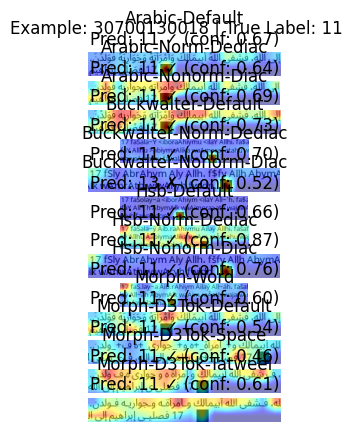

In [ ]:
models, renderers, datasets = load_models(diac_variants, load_datasets=False)

output_dir = Path(OUTPUT_DIR) / 'diac_comparisons'

count = 0

for _, id, label, sentence in labeled_sentences.itertuples():
    create_comparison_figure(id, sentence, label, diac_variants, output_dir, models, renderers)
    count += 1


# Morph Variants

In [5]:
morph_variants = [
    "morph-word",
    "morph-d3tok-tatweel",
    "morph-d3tok-space",
    "morph-d3tok-default"
]

# master_df['interesting'] = (
#     (master_df['label'] != master_df['pred_word-baseline']) &
#     (master_df['label'] == master_df['pred_d3tok-tatweel']) &
#     # (master_df['label'] == master_df['pred_d3tok-space']) &
#     # and confidence > 0.6 for all models
#     (master_df['confidence_d3tok-tatweel'] > 0.5) &
#     # (master_df['confidence_d3tok-space'] > 0.5) &
#     (master_df['label'].isin([11])) 
#     # sentence length > 80
#     # (master_df['sentence'].str.len() > 80)
# )

interesting_examples_ids = [10102390010, 20700880011, 20100290003]

master_df['interesting'] = master_df['id'].isin(interesting_examples_ids)

labeled_sentences = master_df[master_df['interesting']][['id', 'label', 'sentence']].sort_values(by='label', ascending=False)

2025-10-15 19:34:58,982 - INFO - Loading models and renderers...
2025-10-15 19:34:58,983 - INFO - Loading model for morph-word...
2025-10-15 19:35:00,324 - INFO - Loading renderer for morph-word...
2025-10-15 19:35:00,325 - INFO - loading text renderer configuration file ../runs/pixel-base-arabic-default-256-32-1-2.5e-05-5-42/text_renderer_config.json
2025-10-15 19:35:00,326 - INFO - loading font file ../runs/pixel-base-arabic-default-256-32-1-2.5e-05-5-42/GoNotoCurrent.ttf
2025-10-15 19:35:00,326 - INFO - Loading font from ../runs/pixel-base-arabic-default-256-32-1-2.5e-05-5-42/GoNotoCurrent.ttf
2025-10-15 19:35:00,336 - INFO - Text renderer PangoCairoTextRenderer {
  "background_color": "white",
  "dpi": 120,
  "font_color": "black",
  "font_features": null,
  "font_file": "GoNotoCurrent.ttf",
  "font_size": 8,
  "fonts_list": [
    "Abyssinica SIL",
    "Ani",
    "AnjaliOldLipi",
    "Bitstream Vera Sans",
    "Bitstream Vera Sans Mono",
    "Bitstream Vera Serif",
    "C059",
    

بعض التقديرات الحديثة تُقدّر حدوث تلك اللحظة قبل 13.8 مليار سنة، والذي يُعد عمر الكون.


2025-10-15 19:35:07,551 - INFO - Setting up morphological tokenizer...
2025-10-15 19:35:07,657 - INFO - Loading CAMeL Tools disambiguator...
2025-10-15 19:35:10,955 - INFO - Setting up morphological tokenizer...
2025-10-15 19:35:11,052 - INFO - Loading CAMeL Tools disambiguator...
2025-10-15 19:35:13,764 - INFO - Setting up morphological tokenizer...


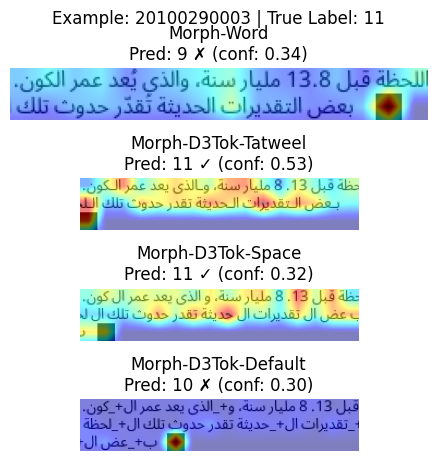

2025-10-15 19:35:14,071 - INFO - Loading CAMeL Tools disambiguator...


يمكنك أن تقول إنه من أنكر الأصوات


2025-10-15 19:35:17,631 - INFO - Setting up morphological tokenizer...
2025-10-15 19:35:17,709 - INFO - Loading CAMeL Tools disambiguator...
2025-10-15 19:35:20,792 - INFO - Setting up morphological tokenizer...
2025-10-15 19:35:20,866 - INFO - Loading CAMeL Tools disambiguator...
2025-10-15 19:35:23,549 - INFO - Setting up morphological tokenizer...


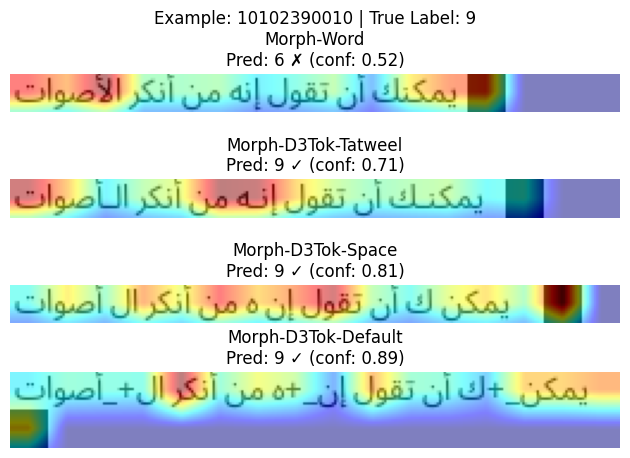

2025-10-15 19:35:23,840 - INFO - Loading CAMeL Tools disambiguator...


وقد شهدت دولة الإمارات تطورا كبيرا في مجال الرعاية الصحية ،


2025-10-15 19:35:27,218 - INFO - Setting up morphological tokenizer...
2025-10-15 19:35:27,307 - INFO - Loading CAMeL Tools disambiguator...
2025-10-15 19:35:30,432 - INFO - Setting up morphological tokenizer...
2025-10-15 19:35:30,511 - INFO - Loading CAMeL Tools disambiguator...
2025-10-15 19:35:33,659 - INFO - Setting up morphological tokenizer...


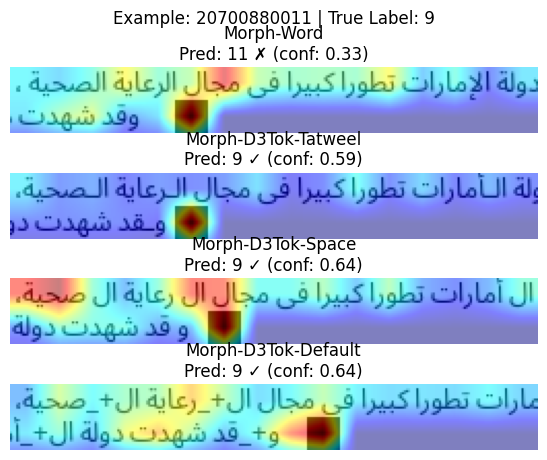

In [6]:
models, renderers, datasets = load_models(morph_variants, load_datasets=False)

output_dir = Path(OUTPUT_DIR) / 'morph_comparisons'

count = 0

for _, id, label, sentence in labeled_sentences.itertuples():
    create_comparison_figure(id, sentence, label, morph_variants, output_dir, models, renderers)
    count += 1


# Script Variants

In [7]:

script_variants = [
    "arabic-default",
    "buckwalter-default",
    "hsb-default",
]
    # (6, "سُلوكي مَسْؤليَّتي"),
    # (14, "لا أحد يجمع هذه الزهور معًا في باقة, فهي منتشرة جدًّا — حتى إنه كان من المعروف عنها تنمو بين أحجار الرصف, وتنبثق في كل مكان مثل الحشانش الضارة — وتحمل اسمًا قبيحًا جدًّا وهو «زهور الكلاب» أو «الهندباء البرية»."),
    # (9, "وقال بكلام فصيح مزعج: يا سمك يا سمك هل أنت على العهد القديم مقيم"),

interesting_examples_ids = [
                            30700130018, # Genesis, ibrahim <3
                            30900050032,30900020039,20300070033, 20800110068,
                            10102450016, # high confidence, length based
                            30100230143, # Different reasonings, all with high confidence
                            30500300032,
                            20400230031, # Different reasonings, all with high confidence
                            10400320023,
                            ]

# take rows where all variants agree and are correct
# columns are: label. pred_arabic-default, pred_buckwalter-default, pred_hsb-default
# master_df['interesting'] = (
#     (master_df['label'] == master_df['pred_arabic-default']) &
#     (master_df['label'] == master_df['pred_buckwalter-default']) &
#     (master_df['label'] == master_df['pred_hsb-default']) &
#     # and confidence > 0.35 for all models
#     (master_df['confidence_arabic-default'] > 0.6) &
#     (master_df['confidence_buckwalter-default'] > 0.6) &
#     (master_df['confidence_hsb-default'] > 0.6) &
#     (master_df['label'].isin([11])) &
#     # sentence length > 80
#     (master_df['sentence'].str.len() > 80)
# )

master_df['interesting'] = master_df['id'].isin(interesting_examples_ids)

labeled_sentences = master_df[master_df['interesting']][['id', 'label', 'sentence']].sort_values(by='label', ascending=False)

2025-10-15 19:35:33,975 - INFO - Loading models and renderers...
2025-10-15 19:35:33,976 - INFO - Loading model for arabic-default...
2025-10-15 19:35:35,540 - INFO - Loading renderer for arabic-default...
2025-10-15 19:35:35,541 - INFO - loading text renderer configuration file ../runs/pixel-base-arabic-default-256-64-1-5e-05-7-42/text_renderer_config.json
2025-10-15 19:35:35,542 - INFO - loading font file ../runs/pixel-base-arabic-default-256-64-1-5e-05-7-42/GoNotoCurrent.ttf
2025-10-15 19:35:35,543 - INFO - Loading font from ../runs/pixel-base-arabic-default-256-64-1-5e-05-7-42/GoNotoCurrent.ttf
2025-10-15 19:35:35,557 - INFO - Text renderer PangoCairoTextRenderer {
  "background_color": "white",
  "dpi": 120,
  "font_color": "black",
  "font_features": null,
  "font_file": "GoNotoCurrent.ttf",
  "font_size": 8,
  "fonts_list": [
    "Abyssinica SIL",
    "Ani",
    "AnjaliOldLipi",
    "Bitstream Vera Sans",
    "Bitstream Vera Sans Mono",
    "Bitstream Vera Serif",
    "C059",
  

فَتُغْـلِلْ لَكُمْ مَا لاَ تُغِـلُّ لأَهْلِهَـا قُـرَىً بِالْعِـرَاقِ مِنْ قَفِيْزٍ وَدِرْهَـمِ


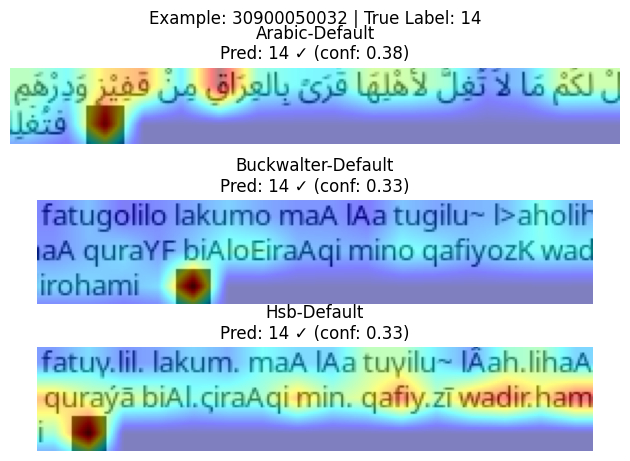

إلاّ مــقــالــة َ أقــوامٍ شَــقــــيــتُ بــهـــا كــــانَــــتْ مــــقــالَــتُــهُــمْ قَـرْعًا على الكَبــِـدِ


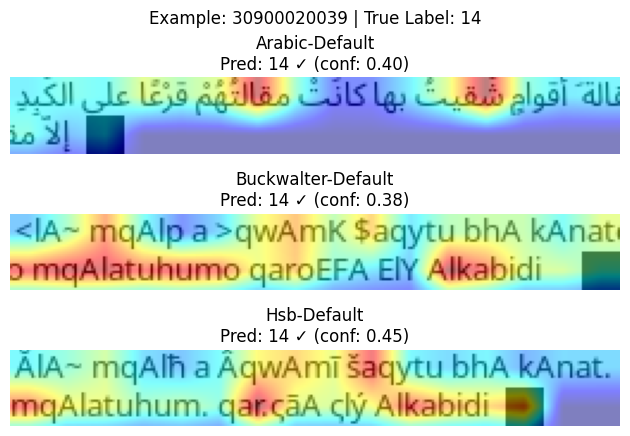

وقال سموه: القراءة هي المهارة الأولى التي يحتاجها أبناؤنا، والحكومة وظيفتها ليس فقط تقديم الخدمات بل بناء العقول والمهارات، والمرحلة القادمة من التنمية في الإمارات، تحتاج لجيل مثقف قارئ يمتلكه شغف الفضول، وحب الاستطلاع وعمق التعلم.


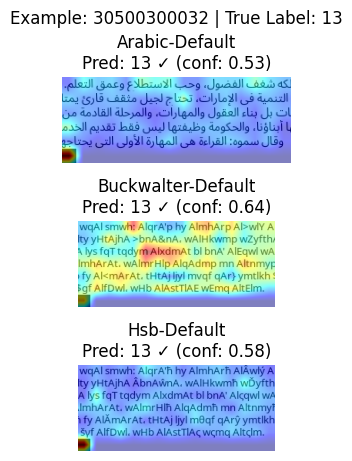

إذا كنت تقومين بطهي أي نوع من الخضروات وأفرطت في طهيه يمكن إضافته إلى ملعقة من الزبادي والتوابل وخفقه في الخلاط،


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 3 has a total capacity of 23.59 GiB of which 5.00 MiB is free. Including non-PyTorch memory, this process has 23.57 GiB memory in use. Of the allocated memory 20.96 GiB is allocated by PyTorch, and 2.30 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

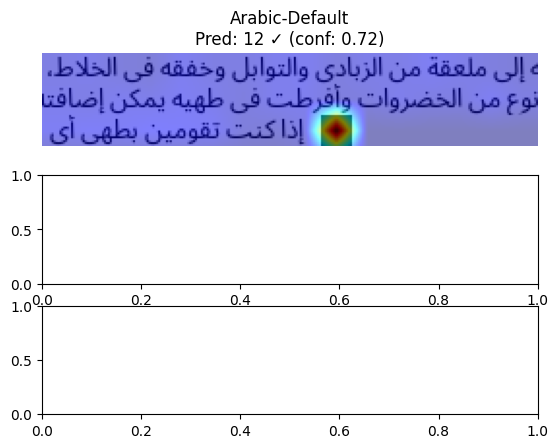

In [8]:
models, renderers, datasets = load_models(script_variants, load_datasets=False)

output_dir = Path(OUTPUT_DIR) / 'script_comparisons'

count = 0

for _, id, label, sentence in labeled_sentences.itertuples():
    create_comparison_figure(id, sentence, label, script_variants, output_dir, models, renderers)
    count += 1


In [ ]:
labeled_sentences = [
    (1, "أَرْنب"),
    (2, "ملعبٌ واسعٌ"),
    (3, "أنا أحب اللون الأحمر."),
    (4, "الشمس تشرق في الصباح الباكر."),
    (5, "القطة تستريح على السرير وتستمتع بأشعة الشمس الدافنة."),
    (6, "سُلوكي مَسْؤليَّتي"),
    (7, "الأصدقاء يحتفلون بعيد ميلاد صديقهم بكعكة وهدايا رائعة."),
    (8, "أستمع إِلى كل فقرة من الفقرتين, ثم أجيب:"),
    # (8, "أَسْتَمِعُ إِلى كُلَّ فِقْرِةٍ مِنَ الفِقْرَتَيْنِ, ثُمَّ أُجيبُ:"),
    (9, "وقال بكلام فصيح مزعج: يا سمك يا سمك هل أنت على العهد القديم مقيم"),
    (10, "وَسَأَلْتُكَ هَلْ كُنْتُمْ تَتَّهِمُونَهُ بِالْكَذِبِ قَبْلَ أَنْ يَقُولَ مَا قَالَ فَذَكَرْتَ أَنْ لاَ,"),
    (11, "حسام سعيدٌ قلبُه بسبب فوز فريقه."),
    (12, "لا أحد يجمع هذه الزهور معًا في باقة, فهى منتشرة جدًّا — حتى إنه كان من المعروف عنها أنها تنمو بين أحجار الرصف, وتنبثق في كل مكان مثل الحشائش الضارة — وتحمل اسمًا قبيحًا جدًّا وهو «زهور الكلاب» أو «الهندباء البرية»."),
    (13, "ومن يفعل المعروف مع غير أهله يجازَ كما جوزي مجير أم عامر"),
    (14, "لا أحد يجمع هذه الزهور معًا في باقة, فهي منتشرة جدًّا — حتى إنه كان من المعروف عنها تنمو بين أحجار الرصف, وتنبثق في كل مكان مثل الحشانش الضارة — وتحمل اسمًا قبيحًا جدًّا وهو «زهور الكلاب» أو «الهندباء البرية»."),
    (15, "وكان من عادتها أن تقارن بينها وبين بطلة الرواية إذا أحسَّت منه إعجابًا بها أو ثناءً عليها, وتسأله في ذلك أسئلةً ذكيةً خبيثةً لا تسهل المغالطة في جوابها, إلا على سبيل المزاح والمداعبة."),
    (16, "ويذهب المؤرخون إلى أن النابغة الذبياني كان من المُحَكّمين, تقام له في هذه الأسواق قبة يذهب إليها الشعراء ليعرضوا شعرهم, فمن أشاد به ذاع صيته, وتناقلت شعره الركبان."),
    (17, "بين طعن القَنا وخَفْق البُنودِ"),
    (18, "إلاّ الأواريَّ لأيًا ما أُبَيّنُهَا والنُّؤيُ كالحَوْضِ بالمَظلومَة الجَلَد"),
    (19, "كأن حدوج المالكية غدوةً خلايا سفين بالنواصف من دد")
]